# Дообучние ViT в 2 этапа + расширенные и улучшенные аугментации

* Качество на тесте: 0.58
* Качество на валидации: 0.84

In [1]:
import sys

from pathlib import Path
import os
from glob import glob

import pandas as pd
import numpy as np

from PIL import Image

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import pytorch_lightning as pl
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sneakers_hse.model.baseline_cnn import LitCNN
from sneakers_hse.model.resnet_18 import LitResNet18
from sneakers_hse.model.dataset import ImageDataset
from sneakers_hse.model.streaming_dataset import StreamingImageDataset
from sneakers_hse.model.classifier import LitClassifier

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

import matplotlib.pyplot as plt

from litdata import optimize
import fsspec

from tqdm import tqdm
tqdm.pandas()

%load_ext autoreload
%autoreload 2

In [2]:
train_df_pre = pd.read_csv('../../data/03_yolo_preprocessed/train_images.csv')
display(train_df_pre.head(), train_df_pre.shape)

test_df = pd.read_csv('../../data/03_yolo_preprocessed/test_images.csv')
display(test_df.head(), test_df.shape)

,Unnamed: 0,path,sneaker_class,corrupted_flg
0,0,Vans Кеды Upland/clothing_0_264.jpeg,Vans Кеды Upland,0
1,1,Vans Кеды Upland/clothing_0_57.jpeg,Vans Кеды Upland,0
2,2,Vans Кеды Upland/orig_45.jpeg,Vans Кеды Upland,0
3,3,Vans Кеды Upland/clothing_0_0.jpeg,Vans Кеды Upland,0
4,4,Vans Кеды Upland/clothing_0_233.jpeg,Vans Кеды Upland,0


(10965, 4)

,Unnamed: 0,path,sneaker_class,corrupted_flg
0,14,Vans Кеды Upland/clothing_0_168_real.jpeg,Vans Кеды Upland,0
1,32,Vans Кеды Upland/clothing_0_215_real.jpeg,Vans Кеды Upland,0
2,44,Vans Кеды Upland/orig_216_real.jpeg,Vans Кеды Upland,0
3,80,Vans Кеды Upland/shoe_3_100_real.jpeg,Vans Кеды Upland,0
4,87,Vans Кеды Upland/clothing_0_277_real.jpeg,Vans Кеды Upland,0


(300, 4)

In [3]:
train_df, val_df = train_test_split(
    train_df_pre,
    test_size=0.2,
    stratify=train_df_pre["sneaker_class"],
    random_state=42
)

display(train_df.head(), train_df.shape)
display(val_df.head(), val_df.shape)
display(test_df.head(), test_df.shape)

,Unnamed: 0,path,sneaker_class,corrupted_flg
2195,2288,Nike Кеды Dunk Low Retro/clothing_0_103.jpeg,Nike Кеды Dunk Low Retro,0
10557,10855,PUMA Кроссовки Puma Morphic/orig_111.jpeg,PUMA Кроссовки Puma Morphic,0
7299,7477,Kari Кроссовки/clothing_0_190.jpeg,Kari Кроссовки,0
4103,4230,Reebok Кроссовки CLASSIC LEATHER/clothing_0_43...,Reebok Кроссовки CLASSIC LEATHER,0
2097,2188,Nike Кеды Dunk Low Retro/clothing_0_86.jpeg,Nike Кеды Dunk Low Retro,0


(8772, 4)

,Unnamed: 0,path,sneaker_class,corrupted_flg
7461,7639,Vans Кеды Knu Skool/clothing_0_98.jpeg,Vans Кеды Knu Skool,0
2486,2591,Reebok Кроссовки CLASSIC NYLON/orig_291.jpeg,Reebok Кроссовки CLASSIC NYLON,0
4889,5027,Nike Кроссовки AIR MAX 90/clothing_0_12.jpeg,Nike Кроссовки AIR MAX 90,0
2655,2762,Under Armour Кроссовки UA CHARGED SPEED SWIFT/...,Under Armour Кроссовки UA CHARGED SPEED SWIFT,0
231,240,Vans Кеды Upland/clothing_0_62.jpeg,Vans Кеды Upland,0


(2193, 4)

,Unnamed: 0,path,sneaker_class,corrupted_flg
0,14,Vans Кеды Upland/clothing_0_168_real.jpeg,Vans Кеды Upland,0
1,32,Vans Кеды Upland/clothing_0_215_real.jpeg,Vans Кеды Upland,0
2,44,Vans Кеды Upland/orig_216_real.jpeg,Vans Кеды Upland,0
3,80,Vans Кеды Upland/shoe_3_100_real.jpeg,Vans Кеды Upland,0
4,87,Vans Кеды Upland/clothing_0_277_real.jpeg,Vans Кеды Upland,0


(300, 4)

In [4]:
train_paths = train_df["path"].tolist()
val_paths   = val_df["path"].tolist()
test_paths  = test_df["path"].tolist()

train_labels = train_df["sneaker_class"].tolist()
val_labels   = val_df["sneaker_class"].tolist()
test_labels  = test_df["sneaker_class"].tolist()

In [5]:
train_tfms = A.Compose([
    A.RandomResizedCrop(
        size=(224, 224),
        scale=(0.7, 1.0),
        ratio=(0.75, 1.33),
        p=1.0
    ),

    A.HorizontalFlip(p=0.5),

    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(0.0, 0.1),
        rotate=(-15, 15),
        shear=(-10, 10),
        p=0.7
    ),

    A.Perspective(scale=(0.02, 0.08), p=0.5),

    A.OneOf([
        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2
        ),
        A.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.05
        ),
    ], p=0.7),

    A.OneOf([
        A.MotionBlur(blur_limit=5),
        A.GaussianBlur(blur_limit=5),
    ], p=0.3),

    A.GaussNoise(std_range=(0.03, 0.08), p=0.3),

    A.CoarseDropout(
        num_holes_range=(1, 2),
        hole_height_range=(11, 34),
        hole_width_range=(11, 34),
        fill=0,
        p=0.5
    ),

    A.ImageCompression(quality_range=(40, 100), p=0.3),

    A.RandomShadow(
        shadow_roi=(0, 0.5, 1, 1),
        num_shadows_limit=(1, 2),
        shadow_intensity_range=(0.3, 0.6),
        p=0.2
    ),

    A.RandomFog(fog_coef_range=(0.1, 0.3), p=0.15),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

In [6]:
path_to_dataset = '../../data/03_yolo_preprocessed/search-dataset-images'

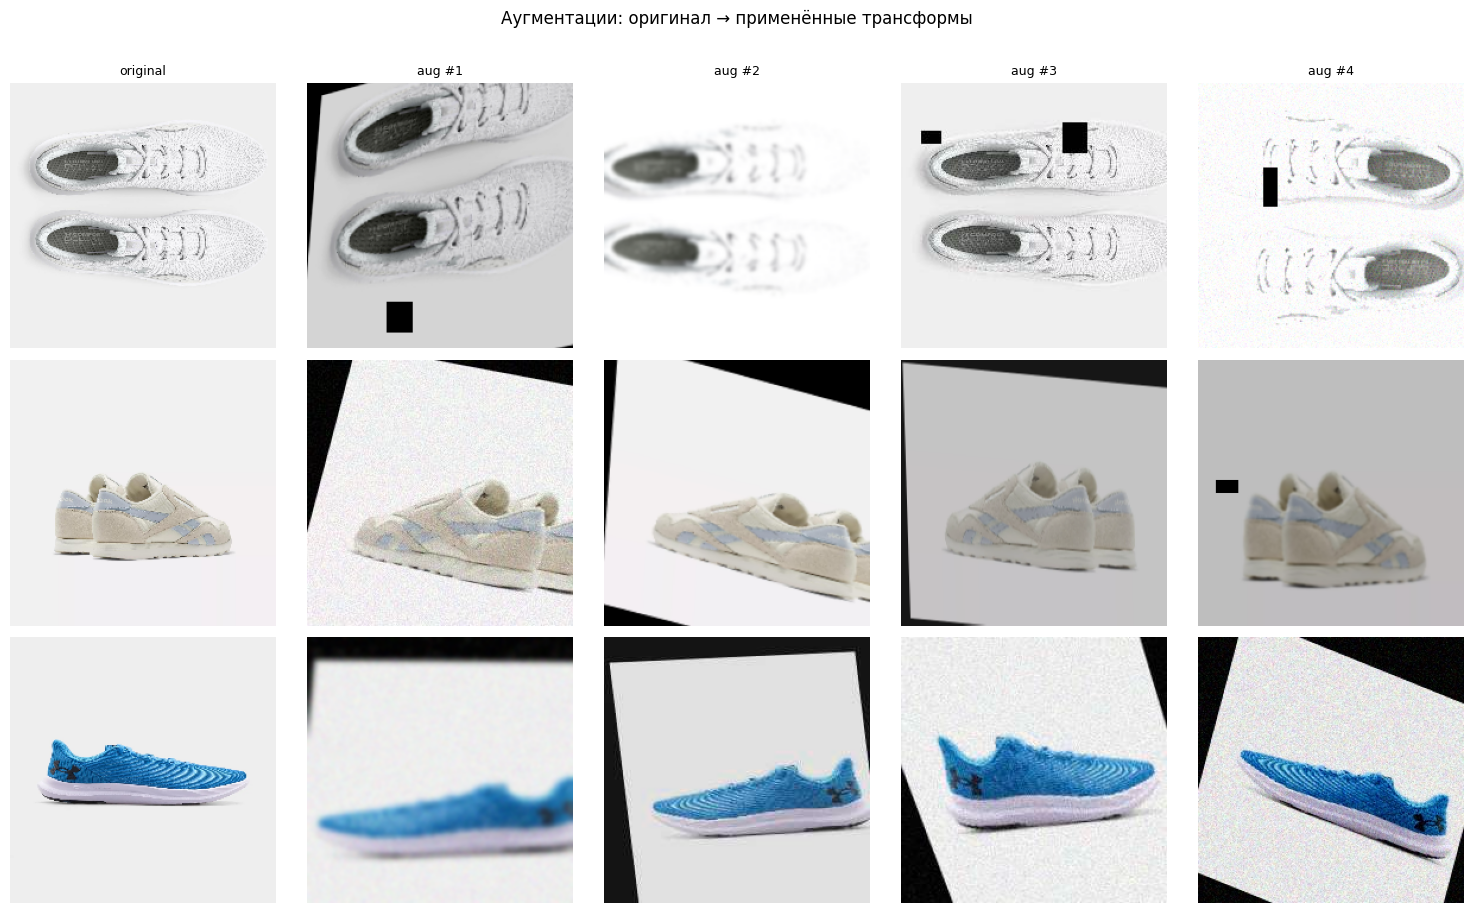

In [7]:
vis_tfms = A.Compose([
    t for t in train_tfms.transforms
    if not isinstance(t, (A.Normalize, ToTensorV2))
])

N_IMAGES = 3
N_AUG = 4

fig, axes = plt.subplots(N_IMAGES, N_AUG + 1, figsize=(3 * (N_AUG + 1), 3 * N_IMAGES))

sample_paths = train_df.sample(N_IMAGES, random_state=7)["path"].tolist()

for row, rel_path in enumerate(sample_paths):
    img = np.array(Image.open(os.path.join(path_to_dataset, rel_path)).convert("RGB"))
    orig = A.Resize(224, 224)(image=img)["image"]

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title("original" if row == 0 else "", fontsize=9)
    axes[row, 0].axis("off")

    for col in range(N_AUG):
        aug = vis_tfms(image=img)["image"]
        axes[row, col + 1].imshow(aug)
        axes[row, col + 1].set_title(f"aug #{col + 1}" if row == 0 else "", fontsize=9)
        axes[row, col + 1].axis("off")

plt.suptitle("Аугментации: оригинал → применённые трансформы", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
all_classes = sorted(set(train_labels + val_labels + test_labels))
class_to_idx = {c: i for i, c in enumerate(all_classes)}

In [9]:
train_dataset = ImageDataset(
    base_path=path_to_dataset,
    images_path=train_paths,
    labels=train_labels,
    augmenter=train_tfms,
    class_to_idx=class_to_idx
)

val_dataset = ImageDataset(
    base_path=path_to_dataset,
    images_path=val_paths,
    labels=val_labels,
    augmenter=val_tfms,
    class_to_idx=class_to_idx
)

test_dataset = ImageDataset(
    base_path=path_to_dataset,
    images_path=test_paths,
    labels=test_labels,
    augmenter=val_tfms,
    class_to_idx=class_to_idx
)

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=8,
    pin_memory=False,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=False,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=False,
    persistent_workers=True,
)

In [11]:
callbacks = [
    ModelCheckpoint(
        monitor="val_loss",
        save_top_k=1,
        mode="min"
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3
    )
]

In [12]:
from sneakers_hse.data.utils.eda_utils import directory_to_dataframe

df = directory_to_dataframe(path_to_dataset)
df.head()

,path,sneaker_class
0,Vans Кеды Upland/clothing_0_264.jpeg,Vans Кеды Upland
1,Vans Кеды Upland/clothing_0_57.jpeg,Vans Кеды Upland
2,Vans Кеды Upland/orig_45.jpeg,Vans Кеды Upland
3,Vans Кеды Upland/clothing_0_0.jpeg,Vans Кеды Upland
4,Vans Кеды Upland/clothing_0_233.jpeg,Vans Кеды Upland


In [13]:
model = LitClassifier(
      model_name="efficientformer_l1",                                                                                                                             
      num_classes=df["sneaker_class"].nunique(),                                                                                                                   
      lr=1e-3,                                  
      freeze_backbone=True,                                                                                                                                        
)
                        
model.load_state_dict(torch.load('../../models/final_fixed_augmented_efficientformer_l1.pth'))

<All keys matched successfully>

## Retrieval-метрики на эмбеддингах ViT

In [14]:
import polars as pl

def extract_embeddings(dataloader, paths, labels, split_name, device):
    model.eval()
    all_embs = []
    with torch.no_grad():
        for x, _ in tqdm(dataloader, desc=f"Extracting {split_name}"):
            x = x.to(device)
            feats = model.model.forward_features(x)
            embs = model.model.forward_head(feats, pre_logits=True)
            all_embs.append(embs.cpu().numpy())
    embeddings = np.vstack(all_embs)
    return pl.DataFrame({
        "path": paths,
        "class": labels,
        "embedding": embeddings.tolist(),
        "sample_part": [split_name] * len(paths),
    })

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
model = model.to(device)

# train без аугментаций и с shuffle=False, чтобы порядок совпал с train_paths
train_loader_noaug = DataLoader(
    ImageDataset(
        base_path=path_to_dataset,
        images_path=train_paths,
        labels=train_labels,
        augmenter=val_tfms,
        class_to_idx=class_to_idx,
    ),
    batch_size=64, shuffle=False, num_workers=8, pin_memory=False, persistent_workers=True,
)

train_emb_df = extract_embeddings(train_loader_noaug, train_paths, train_labels, 'train', device)
val_emb_df   = extract_embeddings(val_loader,         val_paths,   val_labels,   'val',   device)
test_emb_df  = extract_embeddings(test_loader,        test_paths,  test_labels,  'test',  device)

vit_df = pl.concat([train_emb_df, val_emb_df, test_emb_df])
print(f"Итого: {len(vit_df)} эмбеддингов, dim={len(vit_df['embedding'][0])}")

Extracting test: 100%|██████████| 5/5 [00:03<00:00,  1.42it/s]

Итого: 11265 эмбеддингов, dim=448


In [15]:
vit_df.write_parquet('../../data/04_vit_embeddings.parquet.gzip')
print(f"Сохранено {len(vit_df)} эмбеддингов")

Сохранено 11265 эмбеддингов


### Baseline: retrieval-метрики эмбеддингов ViT без triplet

In [16]:
import chromadb
import sys
sys.path.append('../..')
sys.path.append('../../..')
from sneakers_hse.metrics import get_neighbors

all_embs    = np.array(vit_df["embedding"].to_list(), dtype=np.float32)
all_classes = vit_df["class"].to_list()
all_ids     = [str(i) for i in range(len(all_classes))]

client = chromadb.Client()
collection = client.get_or_create_collection("vit_baseline", metadata={"hnsw:space": "cosine"})

for i in range(0, len(all_embs), 5000):
    collection.add(
        ids=all_ids[i:i+5000],
        embeddings=all_embs[i:i+5000].tolist(),
        metadatas=[{"class": c} for c in all_classes[i:i+5000]],
    )

results_baseline = []
for split_name in ["train", "val", "test"]:
    split_df = vit_df.filter(pl.col("sample_part") == split_name)
    embs  = np.array(split_df["embedding"].to_list(), dtype=np.float32)
    labels = np.array(split_df["class"].to_list())
    neighbors = get_neighbors(collection, embs, k=10)
    row = {"split": split_name}
    for k in [1, 5, 10]:
        hits = float(np.mean([labels[i] in neighbors[i][:k] for i in range(len(labels))]))
        prec = float(np.mean([(neighbors[i][:k] == labels[i]).sum() / k for i in range(len(labels))]))
        row[f"hit@{k}"]  = round(hits, 4)
        row[f"prec@{k}"] = round(prec, 4)
    results_baseline.append(row)

client.delete_collection("vit_baseline")
pl.DataFrame(results_baseline)

split,hit@1,prec@1,hit@5,prec@5,hit@10,prec@10
str,f64,f64,f64,f64,f64,f64
"""train""",0.9322,0.9322,0.9838,0.925,0.9904,0.9217
"""val""",0.8482,0.8482,0.9184,0.8233,0.9375,0.8166
"""test""",0.6733,0.6733,0.8,0.6133,0.8333,0.5983


### Обучаем LitTripletModel на эмбеддингах ViT

In [17]:
from sneakers_hse.model.triplet_loss import LitTripletModel, EmbeddingDataset
from torch.utils.data import DataLoader
from pytorch_metric_learning.samplers import MPerClassSampler
import pytorch_lightning as lightning
from pytorch_lightning.loggers import TensorBoardLogger

input_dim = len(vit_df["embedding"][0])
print(f"ViT embedding dim: {input_dim}")

train_pl = vit_df.filter(pl.col("sample_part") == "train")
val_pl   = vit_df.filter(pl.col("sample_part") == "val")

train_dataset_trip = EmbeddingDataset(train_pl)
val_dataset_trip   = EmbeddingDataset(val_pl)

sampler = MPerClassSampler(
    train_dataset_trip.labels_str,
    m=4,
    batch_size=64,
    length_before_new_iter=len(train_dataset_trip),
)

train_loader_trip = DataLoader(train_dataset_trip, batch_size=64, sampler=sampler)
val_loader_trip   = DataLoader(val_dataset_trip,   batch_size=64)

triplet_model = LitTripletModel(input_dim=input_dim, embedding_dim=input_dim, lr=1e-3)

logger = TensorBoardLogger("tb_logs", name="vit_triplet")

trainer_trip = lightning.Trainer(
    max_epochs=30,
    logger=logger,
    enable_checkpointing=False,
    accelerator="mps" if torch.backends.mps.is_available() else "auto",
    devices=1,
)
trainer_trip.fit(triplet_model, train_loader_trip, val_loader_trip)

ViT embedding dim: 448


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential         │  2.0 M │ train │     0 │
│ 1 │ loss_fn │ TripletMarginLoss  │      0 │ train │     0 │
│ 2 │ miner   │ TripletMarginMiner │      0 │ train │     0 │
└───┴─────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 2.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.0 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 12                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.
py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of
the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.
py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value 
of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=30` reached.


### Retrieval-метрики после triplet

In [18]:
triplet_model.eval()
triplet_device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
triplet_model = triplet_model.to(triplet_device)

def encode_with_triplet(df_pl):
    raw = torch.tensor(df_pl["embedding"].to_list(), dtype=torch.float32)
    parts = []
    with torch.no_grad():
        for i in range(0, len(raw), 256):
            parts.append(triplet_model(raw[i:i+256].to(triplet_device)).cpu().numpy())
    return np.vstack(parts)

train_proj = encode_with_triplet(vit_df.filter(pl.col("sample_part") == "train"))
val_proj   = encode_with_triplet(vit_df.filter(pl.col("sample_part") == "val"))
test_proj  = encode_with_triplet(vit_df.filter(pl.col("sample_part") == "test"))

all_proj    = np.vstack([train_proj, val_proj, test_proj])
all_cls_out = vit_df["class"].to_list()
all_ids_out = [str(i) for i in range(len(all_cls_out))]

client = chromadb.Client()
collection = client.get_or_create_collection("vit_triplet", metadata={"hnsw:space": "cosine"})

for i in range(0, len(all_proj), 5000):
    collection.add(
        ids=all_ids_out[i:i+5000],
        embeddings=all_proj[i:i+5000].tolist(),
        metadatas=[{"class": c} for c in all_cls_out[i:i+5000]],
    )

results_triplet = []
for split_name, proj_embs in [("train", train_proj), ("val", val_proj), ("test", test_proj)]:
    labels = np.array(vit_df.filter(pl.col("sample_part") == split_name)["class"].to_list())
    neighbors = get_neighbors(collection, proj_embs, k=10)
    row = {"split": split_name}
    for k in [1, 5, 10]:
        hits = float(np.mean([labels[i] in neighbors[i][:k] for i in range(len(labels))]))
        prec = float(np.mean([(neighbors[i][:k] == labels[i]).sum() / k for i in range(len(labels))]))
        row[f"hit@{k}"]  = round(hits, 4)
        row[f"prec@{k}"] = round(prec, 4)
    results_triplet.append(row)

client.delete_collection("vit_triplet")
pl.DataFrame(results_triplet)

split,hit@1,prec@1,hit@5,prec@5,hit@10,prec@10
str,f64,f64,f64,f64,f64,f64
"""train""",0.9603,0.9603,0.9956,0.9617,0.9972,0.9618
"""val""",0.8404,0.8404,0.8855,0.8177,0.9006,0.8168
"""test""",0.5833,0.5833,0.6933,0.5473,0.72,0.5417
